# Final round 03: sentiment dataset analysis (InSet lexicon counts, Scattertext, TF-IDF word weights)

In [ ]:
DATA_DIR = "."

In [2]:
pip install nlp_id

In [3]:
pip install gensim

In [6]:
pip install scattertext

In [7]:
from collections import Counter

from nlp_id.stopword import StopWord
from nlp_id.postag import PosTag
from nlp_id.lemmatizer import Lemmatizer

from gensim.models import TfidfModel
from gensim.models import LsiModel
from gensim.corpora import Dictionary

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

from imblearn.over_sampling import ADASYN

from xgboost.sklearn import XGBClassifier

# import emoji
import csv
import gdown
import string
import re
import pandas as pd
import numpy as np
import tensorflow as tf
import keras.backend as K

import scattertext as st
from IPython.display import IFrame
from IPython.core.display import display, HTML
from scattertext import CorpusFromPandas, produce_scattertext_explorer
display(HTML("<style>.container { width:98% !important; }</style>"))

import seaborn as sns # untuk visualisasi
import matplotlib.pyplot as plt
plt.style.use('classic')
%matplotlib inline

# potongan kode di bawah adalah agar gambar graph yang
# dihasilkan mempunyai kualitas yang cukup baik
sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
sns.set_context('notebook')
sns.set_style("ticks")

from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

<ipython-input-7-f53281514bdb>:47: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


In [8]:
data = pd.read_csv(f'{DATA_DIR}/Fasilkom CS Zoom Class Experience Survey (Responses) - Form Responses 1.csv')

NameError: name 'pd' is not defined

In [9]:
data.head(3)

In [10]:
data['sentimen'].replace([1.0,0.0], ['Positive', 'Negative'], inplace=True)

KeyError: 'sentimen'

In [11]:
emoticons_str = r"""
    (?:
        [:=;] # Eyes
        [oO\-]? # Nose (optional)
        [D\)\]\(\]/\\OpP] # Mouth
    )"""

regex_str = []
regex_str.append(emoticons_str)
regex_str.append(r'<[^>]+>') # HTML tags
regex_str.append(r'(?:@[\w_]+)') # @-mentions
regex_str.append(r'(?:&[\w_]+)')
regex_str.append(r"(?:\#+[\w_]+[\w\'_\-]*[\w_]+)") # hash-tags
regex_str.append(r'http[s]?://(?:[a-z]|[0-9]|[$-_@.&amp;+]|[!*\(\),]|(?:%[0-9a-f][0-9a-f]))+') # URLs
regex_str.append(r'(?:(?:\d+,?)+(?:\.?\d+)?)') # numbers
regex_str.append(r"(?:[a-z][a-z'\-_]+[a-z])") # words with - and '
regex_str.append(r'(?:[\w_]+)') # other words
regex_str.append(r'(?:\S)') # anything else

tokens_re = re.compile(r'('+'|'.join(regex_str)+')', re.VERBOSE | re.IGNORECASE)
emoticon_re = re.compile(r'^'+emoticons_str+'$', re.VERBOSE | re.IGNORECASE)

def tokenize(sentence):
    return [emoji.demojize(term) for term in tokens_re.findall(sentence)]

In [12]:
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [13]:
# Stopwords Removal & Lemmatizing
lemmatizer = Lemmatizer()
stopword = StopWord()

punctuation = list(string.punctuation)
stops = stopword.get_stopword() + punctuation + ['rt', 'via', '…','•','“']

def remove_stops_and_lemmatize(tokenized_sentence):
  processed_words = []
  for word in tokenized_sentence:
    if word.lower() not in stops:
      processed_words.append(lemmatizer.lemmatize(word))
  return processed_words

In [14]:
def preprocess(sentence):
  #return remove_stops_and_lemmatize(only_allowed_pos(" ".join(tokenize(sentence))))
  return remove_stops_and_lemmatize(tokenize(sentence))

In [ ]:
# kita muat kata-kata bersentiment tersebut ke memori
# dalam bentuk python's dictionary
# key = word
# value = sentiment score

sentword_score = {}

def load_sentword(filename):
  file = open(filename, "r")
  file.readline() # skip header
  for line in file:
    word, score = line.strip().split("\t")
    score = int(score)
    sentword_score[word] = score
  file.close()

load_sentword("negative.tsv")
load_sentword("positive.tsv")

# print(sentword_score)
print(sentword_score['mencederai'])

-4


In [ ]:
data.head()

,source,review_id,user_name,review_title,review_description,rating,thumbs_up,review_date,developer_response,developer_response_date,appVersion,laguage_code,country_code,expedition,sentimen
0,Google Play,2c6973de-c75a-405d-9b9e-e5bf233f200a,Bayu Winalas,NaN,Hingga ini masih baik-baik aja 🥰🥰🥰,5,0,2021-09-02 03:36:26,NaN,NaN,3.13.1,id,id,J&T,Positive
1,Google Play,94fde3c7-4a37-4c92-875c-2f33d585f490,Wahyono 345,NaN,"Terima kasih JNE,selama ini selalu pakai jasa ...",5,1,2020-12-14 14:38:40,NaN,NaN,1.1.14,id,id,JNE,Positive
2,Google Play,31927262-6bd2-4ec5-abe5-757dc7df9a7e,Pengguna Google,NaN,ok lah bisa ngebantu,5,0,2019-03-12 15:29:01,NaN,NaN,3.1.1,id,id,J&T,Positive
3,Google Play,9f71ba44-d15c-438b-b3d0-22f861137f03,Pengguna Google,NaN,langganan,5,0,2019-02-28 00:50:52,NaN,NaN,3.1.1,id,id,J&T,Positive
4,Google Play,b409cdd4-1998-4d48-a486-8a5846e446f4,Pengguna Google,NaN,T O P BGT . . Pengiriman super cepat bgt. .suk...,5,0,2016-05-04 12:17:49,NaN,NaN,NaN,id,id,J&T,Positive


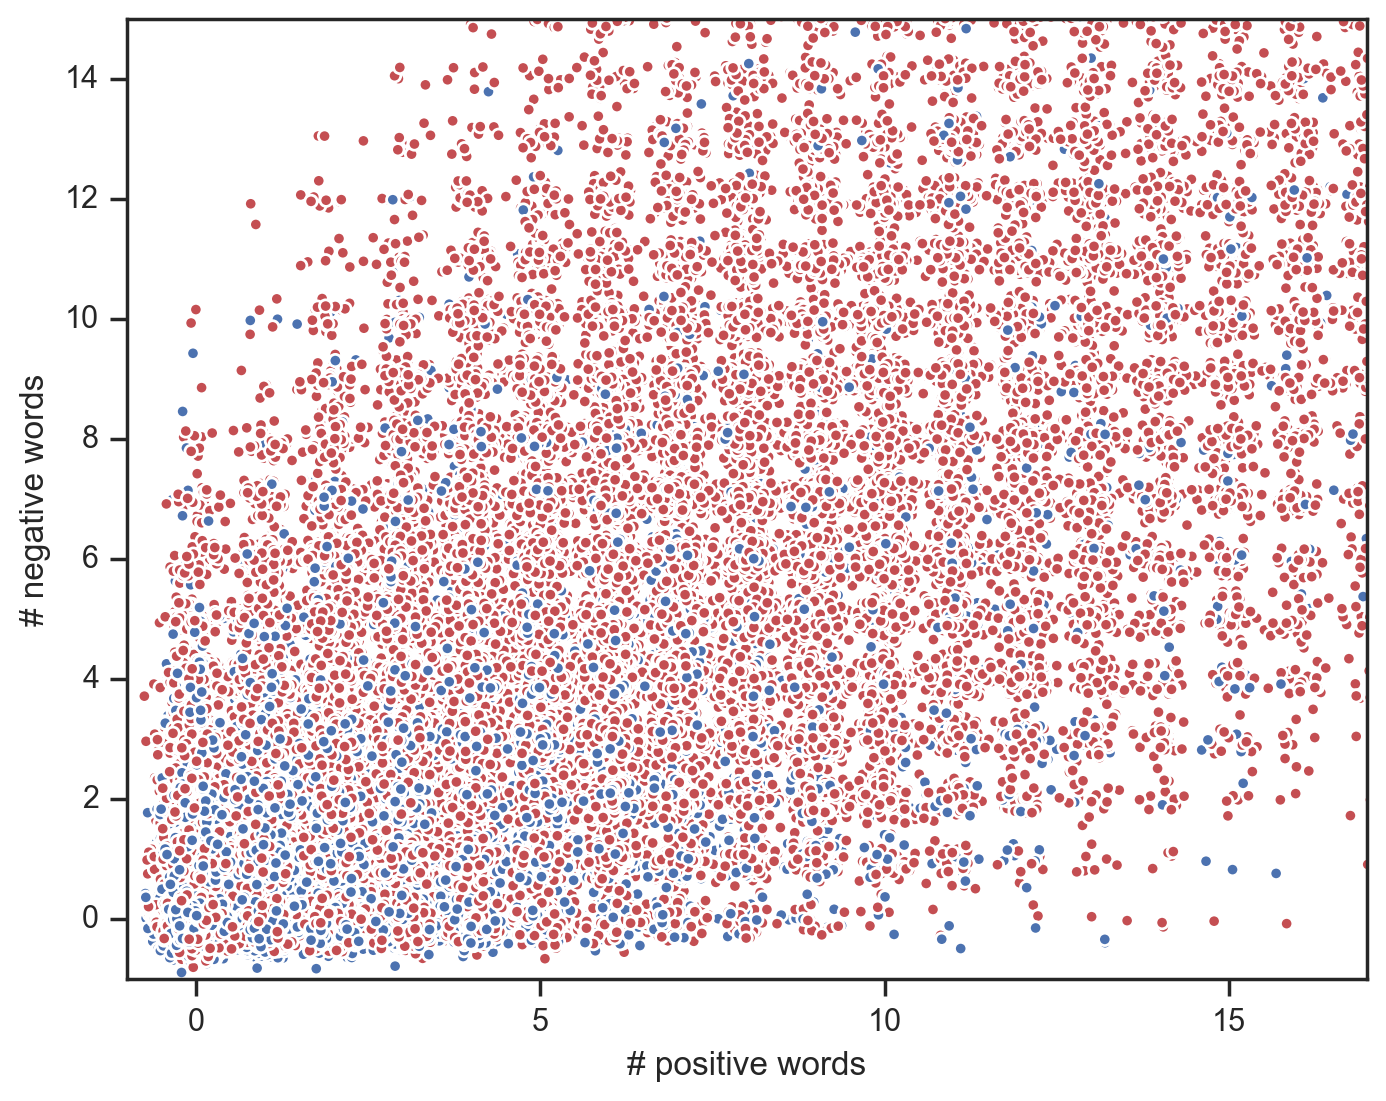

In [ ]:
# kita ingin mengetahui apakah banyaknya kata positif dan banyaknya kata negatif
# di dalam sebuah dokumen bisa menjadi faktor untuk mengklasifikasikan
# the whole document sebagai positif atau negatif.

# kita coba buat scatter plot, dimana x = banyaknya kata positif
# y = banyaknya kata negatif. Lalu, untuk setiap titik (dokumen), diberi warna
# tergantung label dokumen tersebut.

num_pos = []
num_neg = []
scores  = []

# untuk setiap dokumen
for _, row in data.iterrows():
  tokens = tokenize(row["review_description"])
  label = row["sentimen"]
  num_negative, num_positive = 0, 0

  # sekarang, bayangkan sedang di sebuah dokumen
  # untuk setiap kata di dokumen tersebut
  for token in tokens:
    if token in sentword_score:
      if (sentword_score[token] < 0):
        num_negative += 1
      elif (sentword_score[token] > 0):
        num_positive += 1
  num_pos.append(num_positive)
  num_neg.append(num_negative)
  scores.append(label)

# tambahkan kolom di dataframe
data["pos_words"] = num_pos
data["neg_words"] = num_neg

# add jitters
num_pos = np.array(num_pos)
num_neg = np.array(num_neg)
num_pos = num_pos + np.random.normal(0, 0.2, len(num_pos))
num_neg = num_neg + np.random.normal(0, 0.2, len(num_neg))

colors = [('b' if score == 'Positive' else ('r' if score == 'Negative' else 'g')) for score in scores]
plt.scatter(num_pos, num_neg, c = colors)
plt.xlabel('# positive words')
plt.ylabel('# negative words')
plt.xlim(-1, 17)
plt.ylim(-1, 15)
plt.show()

In [ ]:
print("Document Count")
scattext_df = data.copy()
print(scattext_df.groupby('sentimen')['review_description'].count())

print("Word Count")
scattext_df.groupby('sentimen').apply(lambda x: x.review_description.apply(lambda x: len(tokenize(x))).sum())
scattext_df['parsed'] = scattext_df.review_description.apply(st.whitespace_nlp_with_sentences)

# membuat corpus untuk scatter text
corpus = st.CorpusFromParsedDocuments(scattext_df, category_col = 'sentimen', \
                                      parsed_col = 'parsed').build()

html = produce_scattertext_explorer(corpus,
                                    category = 'Positive',
                                    category_name = 'Positive',
                                    not_category_name = 'Negative',
                                    width_in_pixels = 1000,
                                    jitter = 0.1,
                                    minimum_term_frequency = 5,
                                    transform = st.Scalers.percentile)

file_name = 'ReviewJitter.html'
open(file_name, 'wb').write(html.encode('utf-8'))
IFrame(src = file_name, width = 1200, height = 700)

Document Count
sentimen
Negative    69833
Positive    39562
Name: review_description, dtype: int64
Word Count


In [ ]:
from nlp_id.lemmatizer import Lemmatizer
from nlp_id.tokenizer import Tokenizer, PhraseTokenizer
from nlp_id.postag import PosTag
from nlp_id.stopword import StopWord

# uji coba nlp-id
import warnings
warnings.filterwarnings('ignore')

stopwords = StopWord().get_stopword()
lemmatizer = Lemmatizer()
tokenizer = Tokenizer()
postagger = PosTag()
ph_tokenizer = PhraseTokenizer()

def tokenize_lemmatize(text):
  # jika menggunakan nlp-id
  lemmatized_doc = lemmatizer.lemmatize(text)
  return [word for word in tokenizer.tokenize(lemmatized_doc) if word not in stopwords]

In [ ]:
data["lemmatized_review"] = data.review_description.\
                               map(lambda x: ' '.join(tokenize_lemmatize(x)))


In [ ]:
data.lemmatized_review

0                                                    hingga
1         terima kasih jne pakai jasa jne lancar jaya ke...
2                                               ok ngebantu
3                                                   langgan
4            t o p bgt kirim super cepat bgt suka suka suka
                                ...                        
109390    5 bintang j t tp maaf wkt cancel kirim ga pros...
109391                            pra plnggan gk ad kmplain
109392    keren pesan jam 10 pg sampe jam 7 malem pakai ...
109393                       moga pick up d sdkit paket hhi
109394                                bumiayu tercover area
Name: lemmatized_review, Length: 109395, dtype: object

In [ ]:
print("Document Count")
scattext_df = data.copy()
print(scattext_df.groupby('sentimen')['lemmatized_review'].count())

print("Word Count")
scattext_df.groupby('sentimen').apply(lambda x: x.lemmatized_review.apply(lambda x: len(tokenize(x))).sum())
scattext_df['parsed'] = scattext_df.lemmatized_review.apply(st.whitespace_nlp_with_sentences)

# membuat corpus untuk scatter text
corpus = st.CorpusFromParsedDocuments(scattext_df, category_col = 'sentimen', \
                                      parsed_col = 'parsed').build()

html = produce_scattertext_explorer(corpus,
                                    category = 'Positive',
                                    category_name = 'Positive',
                                    not_category_name = 'Negative',
                                    width_in_pixels = 1000,
                                    jitter = 0.1,
                                    minimum_term_frequency = 5,
                                    transform = st.Scalers.percentile)

file_name = 'ReviewJitterLemmatized.html'
open(file_name, 'wb').write(html.encode('utf-8'))
IFrame(src = file_name, width = 1200, height = 700)

Document Count
sentimen
Negative    69833
Positive    39562
Name: lemmatized_review, dtype: int64
Word Count


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
#TF-IDF judul dan konten
data["lemmatized_review"]

vectorizer = TfidfVectorizer(min_df = 3, max_df = .6, ngram_range = (1,2)) #make Tfidf Vectorizer
vectorizer.fit(data["lemmatized_review"])

TfidfVectorizer(max_df=0.6, min_df=3, ngram_range=(1, 2))

In [ ]:
data['sentimen']

0         Positive
1         Positive
2         Positive
3         Positive
4         Positive
            ...   
109390    Negative
109391    Negative
109392    Negative
109393    Positive
109394    Positive
Name: sentimen, Length: 109395, dtype: object

In [ ]:
# average TF-IDF setiap kata pada subset positive dan negative
# hanya memperimbangkan konten, tidak judul
transformed_konten_pos = vectorizer.transform(data[data['sentimen'] == 'Positive']['lemmatized_review'])
transformed_konten_neg = vectorizer.transform(data[data['sentimen'] == 'Negative']['lemmatized_review'])

weights_pos = np.asarray(transformed_konten_pos.mean(axis = 0)).ravel().tolist()
weights_neg = np.asarray(transformed_konten_neg.mean(axis = 0)).ravel().tolist()

weights_df = pd.DataFrame({'term': vectorizer.get_feature_names_out(),
                           'weight_pos': weights_pos,
                           'weight_neg': weights_neg})

weights_df["abs_diff"] = weights_df.apply(lambda x: np.abs(x['weight_pos'] - x['weight_neg']), axis = 1)
weights_df["diff"] = weights_df.apply(lambda x: x['weight_pos'] - x['weight_neg'], axis = 1)

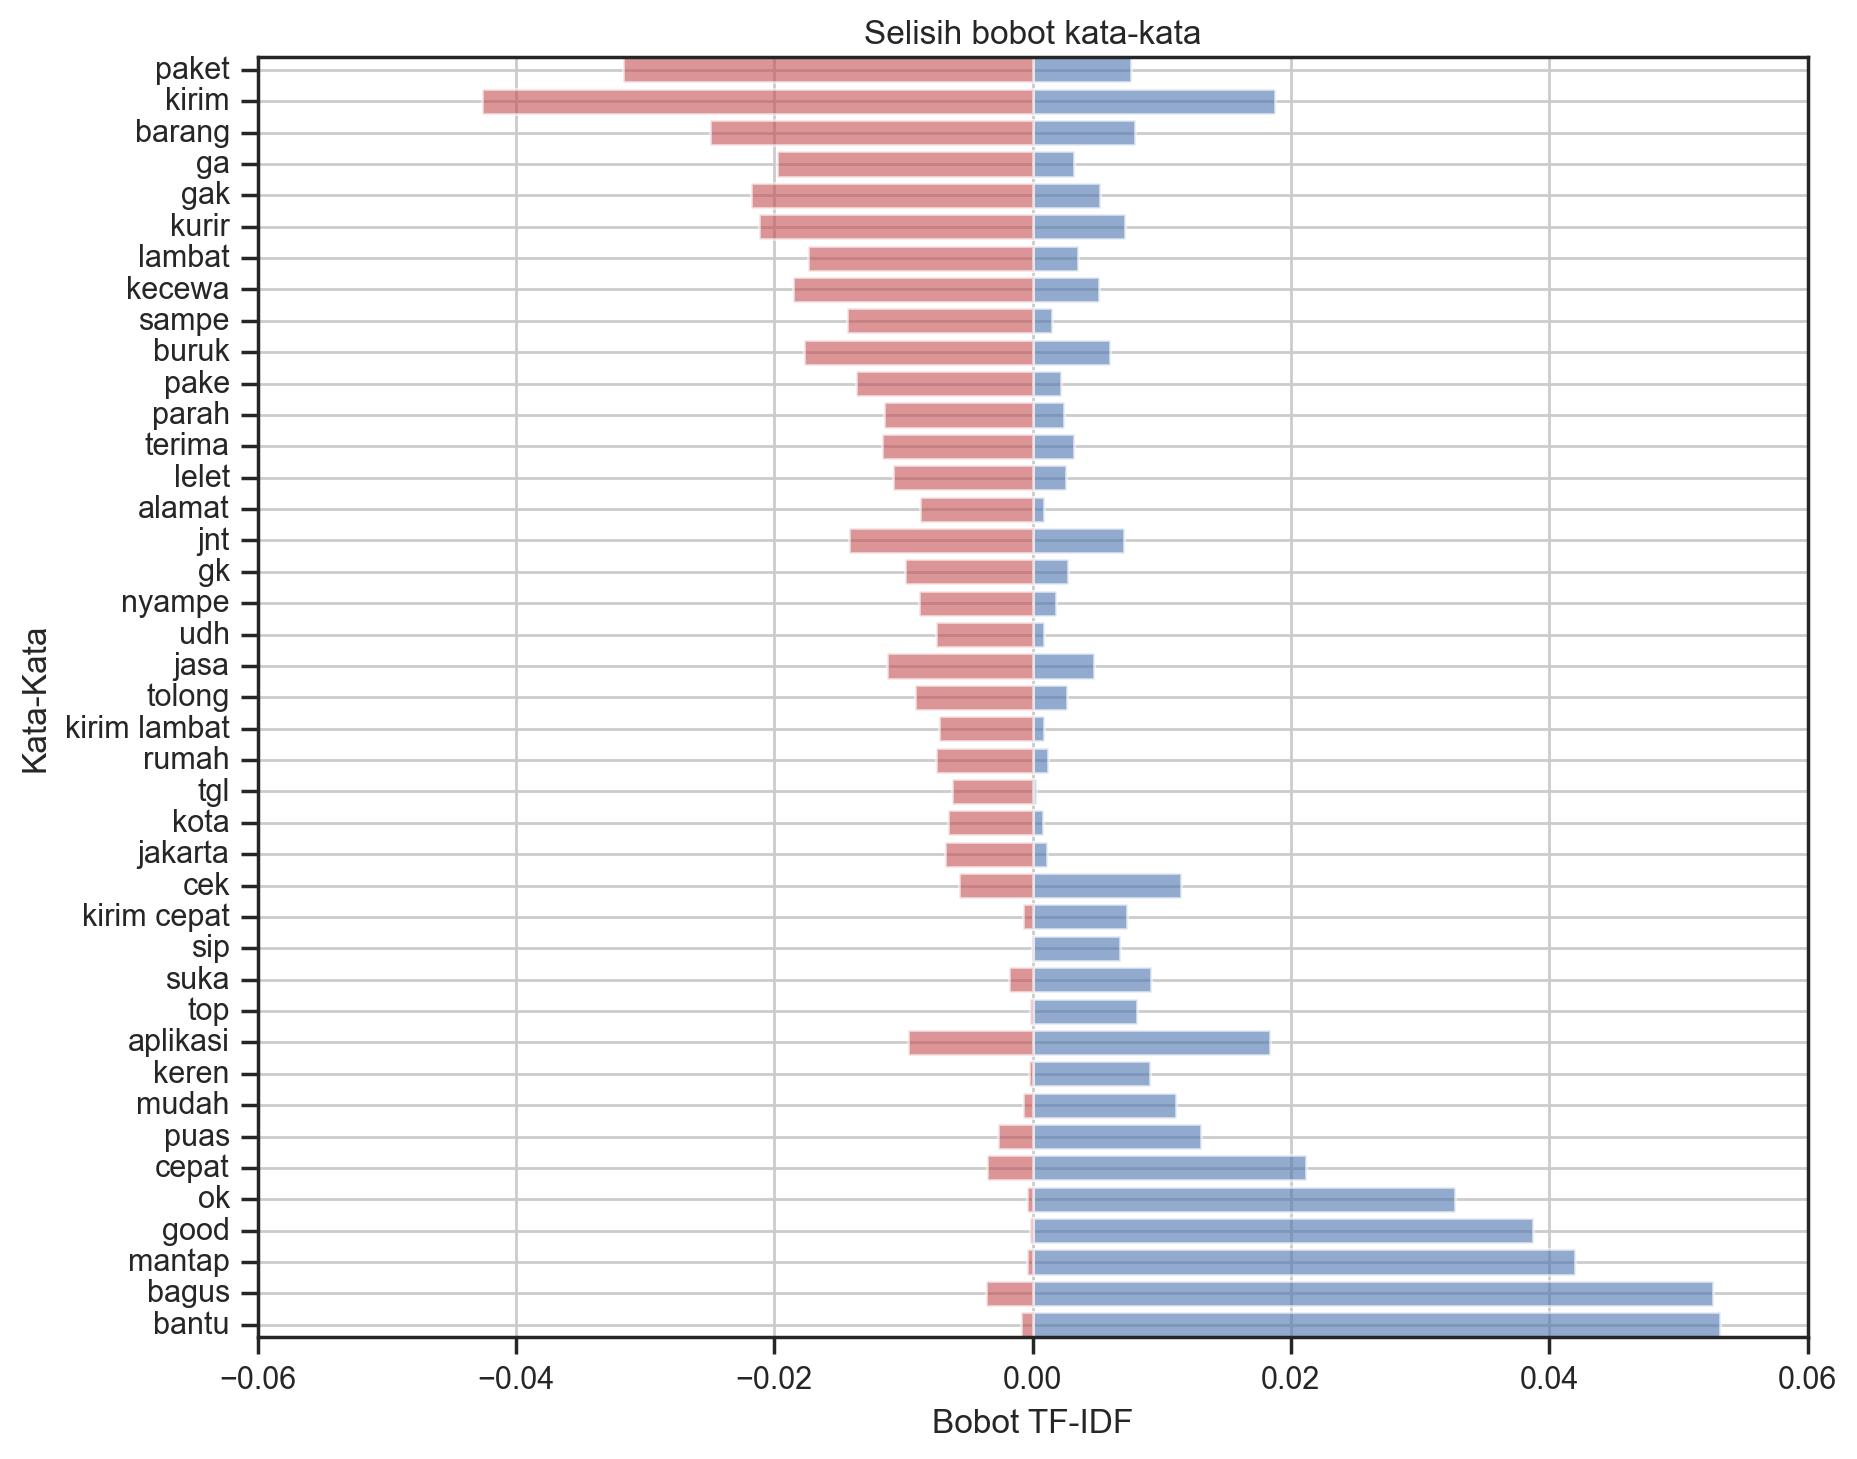

In [ ]:
# plot the bars

weights_df_top = weights_df[weights_df['abs_diff'] > 0.0055].sort_values(by = 'diff', ascending = False)

plt.figure(figsize=(10,8))
plt.grid()
plt.barh(weights_df_top['term'], weights_df_top['weight_pos'], align = 'center',
         alpha = 0.6, color = 'b')

plt.barh(weights_df_top['term'], -weights_df_top['weight_neg'], align = 'center',
         alpha = 0.6, color = 'r')

plt.title("Selisih bobot kata-kata")
plt.ylabel("Kata-Kata")
plt.xlabel("Bobot TF-IDF")
plt.show()